## EDA for real-estate dimension of Gentrification 

This notebook merges the seven separately-built real-estate variables into a single per-PLR table and explores them before they enter the modelling dataset. It inspects distributions (to decide which features need log-transformation), correlation structure (to catch redundant features, including each variable against its district-standardised `vs_bez` counterpart), and outliers, flagging unreliable PLR rather than dropping them. 

The output is a cleaned, `re_`-prefixed feature file (`re_variables.csv`) that feeds into dataset_0, with the district/city relatives retained only as descriptives and excluded from the model-facing set.

In [1]:
import pandas as pd
import pdfplumber
import geopandas as gpd
import os
import numpy as np
import openpyxl as op
from pathlib import Path 
import matplotlib.pyplot as plt

## Step 1: merge all real-estate variables (EDA_input)

In [2]:
csv = Path("../../data/real_estate/final_variables")

#load each variable's saved output (plr_id always as string)
v1 = pd.read_csv(csv / "var1_2_angebotsmieten.csv", dtype={"plr_id": str})
v3 = pd.read_csv(csv / "var3_leerstandsquote.csv", dtype={"plr_id": str})
v4 = pd.read_csv(csv / "var4_mietluecke.csv", dtype={"plr_id": str})
v5 = pd.read_csv(csv / "var5_brw_wohnen_features.csv", dtype={"plr_id": str})
v6 = gpd.read_file("../../data/real_estate/Geodata/var6_DichteAirBNB.gpkg")[
        ["plr_id", "dichte_all", "dichte_entire"]]
v6["plr_id"] = v6["plr_id"].astype(str).str.zfill(8)
v7 = pd.read_csv(csv / "var7_baualter.csv", dtype={"plr_id": str})

#dwelling counts (needed for the applicability flag)
whg = pd.read_excel("../../data/real_estate/raw/Anzahl_whg_PLR.xlsx", skiprows=2, dtype={0: str, 1: str})
whg.columns = ["plr_id", "wohnungen"]
whg = whg[whg["plr_id"].str.match(r"^\d{8}$", na=False)]
whg["wohnungen"] = pd.to_numeric(
    whg["wohnungen"].astype(str).str.replace(".", "", regex=False), errors="coerce")
whg["plr_id"] = whg["plr_id"].str.zfill(8)

#master 542-PLR backbone (use the PLR geofile, the authoritative list)
plr_master = gpd.read_file("../../data/real_estate/Geodata/PLR_raw.geojson")[["plr_id", "plr_name", "bez"]]
plr_master["plr_id"] = plr_master["plr_id"].astype(str).str.zfill(8)
print("Master PLR:", plr_master.shape[0])

#column selections — now include the _vs_bez and _vs_berlin relatives for rents and BRW
v1_cols = ["plr_id",
           "miete_niveau",  "miete_niveau_vs_bez",  "miete_niveau_vs_berlin",
           "miete_trend",   "miete_trend_vs_bez",   "miete_trend_vs_berlin",
           "miete_unsicher"]

v5_cols = ["plr_id",
           "var5_brw_wohnen_niveau",
           "var5_brw_wohnen_niveau_vs_bez", "var5_brw_wohnen_niveau_vs_berlin",
           "var5_brw_wohnen_trend",
           "var5_brw_wohnen_trend_vs_bez",  "var5_brw_wohnen_trend_vs_berlin",
           "var5_brw_wohnen_trend_outlier", "cov_wohnen_2025"]

#merge everything onto the 542-PLR backbone (left joins so no PLR is dropped)
chk = (plr_master
    .merge(v1[v1_cols], on="plr_id", how="left")
    .merge(v3[["plr_id", "leerstandsquote"]], on="plr_id", how="left")
    .merge(v4[["plr_id", "rent_gap"]], on="plr_id", how="left")
    .merge(v5[v5_cols], on="plr_id", how="left")
    .merge(v6, on="plr_id", how="left")
    .merge(v7[["plr_id", "baualter_unsicher"] +
              [c for c in v7.columns if c.startswith("anteil_")]], on="plr_id", how="left")
    .merge(whg, on="plr_id", how="left")
)
assert len(chk) == 542, "Merge hat die PLR-Zahl verändert!"

#applicability flag for the housing dimension
chk["miet_dimension_anwendbar"] = (~(
    chk["wohnungen"].isna() | (chk["wohnungen"] < 30)
)).astype(int)

#missingness map (one representative column per variable; informational, kept for later)
leitspalten = {
    "var1_miete":   "miete_niveau",
    "var3_leer":    "leerstandsquote",
    "var4_gap":     "rent_gap",
    "var5_brw":     "var5_brw_wohnen_niveau",
    "var6_airbnb":  "dichte_all",
    "var7_baualter":"anteil_vor_1919",
}
miss_matrix = pd.DataFrame({lab: chk[col].isna() for lab, col in leitspalten.items()})
chk["n_missing_vars"] = miss_matrix.sum(axis=1)

#summary prints
print("\nMerged shape:", chk.shape)
print("Housing dimension applicable:", int(chk["miet_dimension_anwendbar"].sum()), "of", len(chk))
print("\n--- Missing per variable (of 542 PLR) ---")
for label, col in leitspalten.items():
    print(f"{label:16} fehlt bei {chk[col].isna().sum():3} PLR")
print("\n--- PLR by number of missing variables ---")
print(chk["n_missing_vars"].value_counts().sort_index())
print("\n--- Reliability flags (data present but flagged) ---")
print("miete_unsicher (fallzahl<21):  ", int(chk["miete_unsicher"].fillna(0).sum()))
print("brw_trend_outlier:             ", int(chk["var5_brw_wohnen_trend_outlier"].fillna(0).sum()))
print("brw cov_wohnen < 0.5:          ", int((chk["cov_wohnen_2025"].fillna(0) < 0.5).sum()))
print("baualter_unsicher (<50 Whg):   ", int(chk["baualter_unsicher"].fillna(0).sum()))

#save the EDA input — everything attached, nothing dropped
chk.to_csv(csv / "re_eda_input.csv", index=False)
print("\nsaved EDA input:", chk.shape, "-> re_eda_input.csv")

Master PLR: 542

Merged shape: (542, 33)
Housing dimension applicable: 537 of 542

--- Missing per variable (of 542 PLR) ---
var1_miete       fehlt bei  11 PLR
var3_leer        fehlt bei   5 PLR
var4_gap         fehlt bei  20 PLR
var5_brw         fehlt bei   2 PLR
var6_airbnb      fehlt bei   2 PLR
var7_baualter    fehlt bei   2 PLR

--- PLR by number of missing variables ---
n_missing_vars
0    521
1      9
2      8
3      1
4      1
5      2
Name: count, dtype: int64

--- Reliability flags (data present but flagged) ---
miete_unsicher (fallzahl<21):   142
brw_trend_outlier:              1
brw cov_wohnen < 0.5:           144
baualter_unsicher (<50 Whg):    4

saved EDA input: (542, 33) -> re_eda_input.csv


## Step 2: Distributions 

This step plots a histogram for every candidate feature to judge shape, skew, and missingness before modelling. Each panel reports skew, NaN count, and n, so decisions about which variables need a log-transformation are grounded in the actual distribution. However, the actual transformation and scaling is only done and explained at modelling phase. 

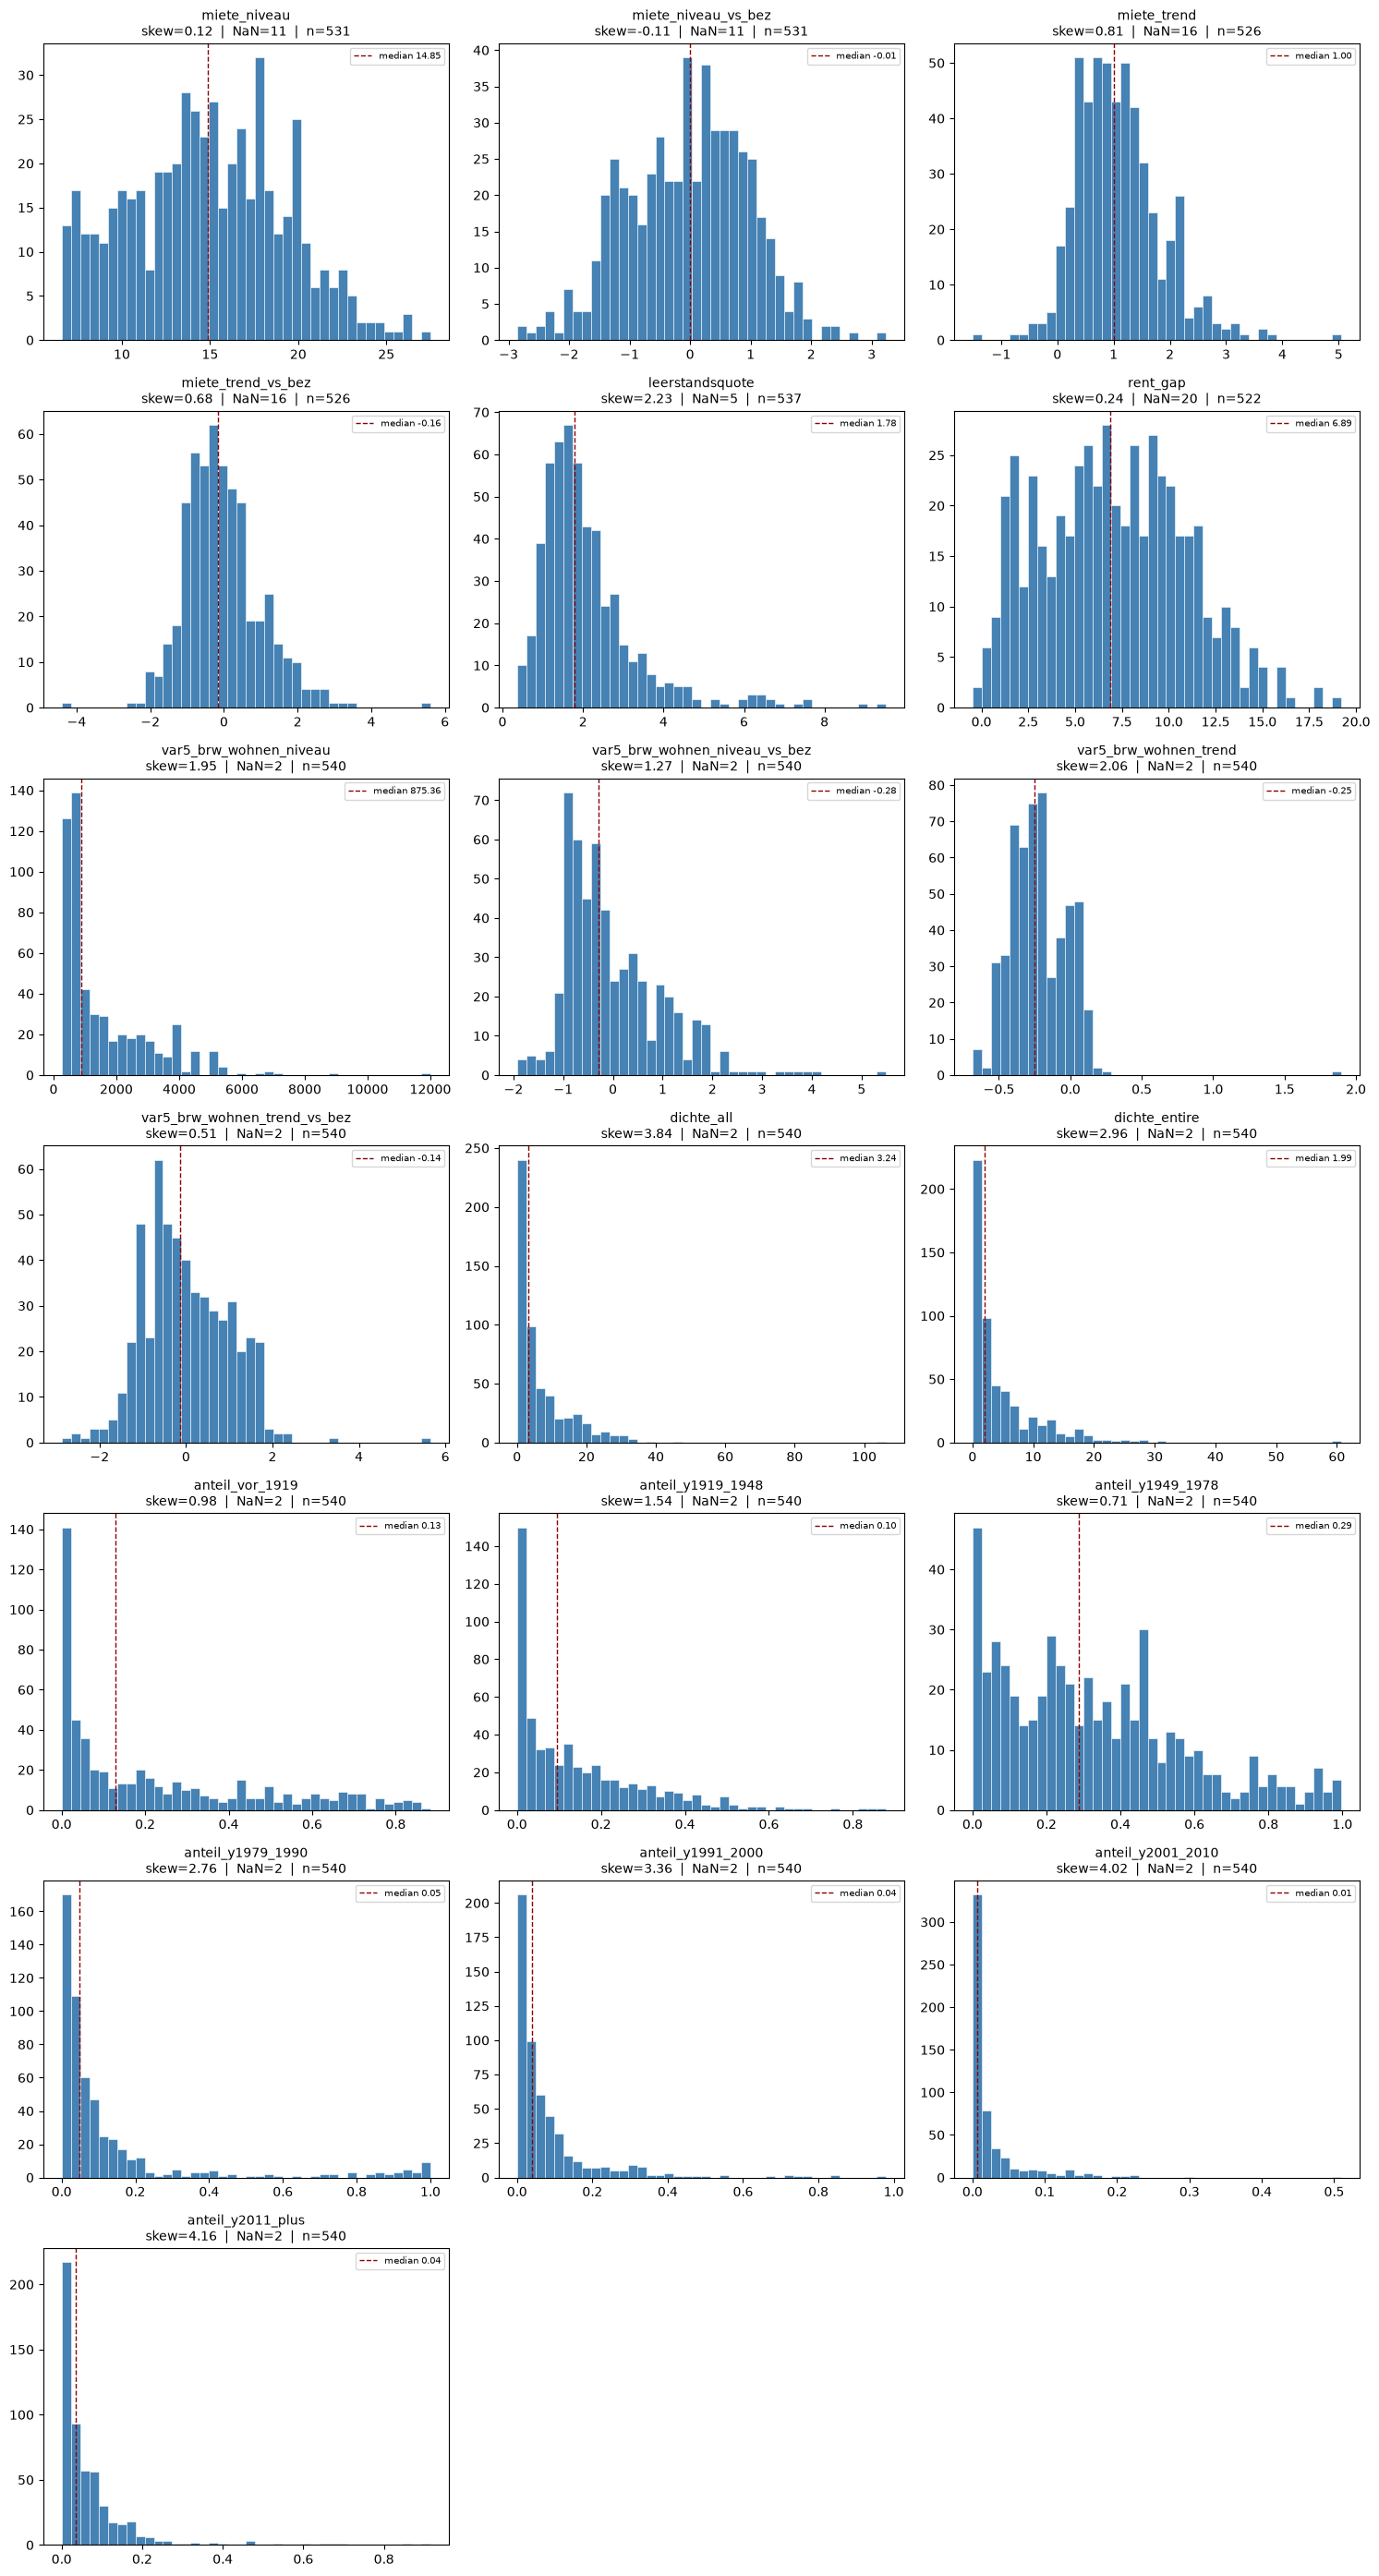

gespeichert: plots/EDA_histograms.png


In [3]:
#plotting histograms to decide which variables need log-transformation 
#clustering set (housing-dimension applicable)
#cs = chk[chk["miet_dimension_anwendbar"] == 1].copy()
cs = chk.copy()

feature_cols = [
    "miete_niveau", "miete_niveau_vs_bez", "miete_trend", "miete_trend_vs_bez", "leerstandsquote", "rent_gap",
    "var5_brw_wohnen_niveau", "var5_brw_wohnen_niveau_vs_bez", "var5_brw_wohnen_trend", "var5_brw_wohnen_trend_vs_bez", "dichte_all", "dichte_entire",
    "anteil_vor_1919", "anteil_y1919_1948", "anteil_y1949_1978",
    "anteil_y1979_1990", "anteil_y1991_2000", "anteil_y2001_2010",
    "anteil_y2011_plus",
]

n = len(feature_cols)
ncols = 3
nrows = -(-n // ncols)  # ceil

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data = cs[col].dropna()
    ax = axes[i]
    ax.hist(data, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
    skew = data.skew()
    n_na = cs[col].isna().sum()
    ax.set_title(f"{col}\nskew={skew:.2f}  |  NaN={n_na}  |  n={len(data)}", fontsize=10)
    ax.axvline(data.median(), color="darkred", linestyle="--", linewidth=1,
               label=f"median {data.median():.2f}")
    ax.legend(fontsize=7)

# hide any unused panels
for j in range(n, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("../../plots/EDA/real_estate/EDA_histograms.png", dpi=110, bbox_inches="tight")
plt.show()
print("gespeichert: plots/EDA_histograms.png")



## Result — Distribution Overview

Across the 19 features, three shapes emerge. 

Roughly symmetric and usable as-is are the rent measures and their district-relatives — miete_niveau (skew 0.12), miete_trend (0.81), rent_gap (0.24), and the vs_bez standardisations, which centre near zero by construction. 

Moderately right-skewed are the older age shares, anteil_y1949_1978 (0.71) and anteil_vor_1919 (0.98), spread across the full 0–1 range. 

Strongly right-skewed, with most PLR near zero and a thin tail of hotspots, are leerstandsquote (2.23), var5_brw_wohnen_niveau (1.95), the Airbnb densities (dichte_all 3.84, dichte_entire 2.96), the BRW trend (2.06, driven by one extreme PLR), and the recent-construction shares (up to anteil_y2011_plus at 4.16). 

This heavy-tailed group is the classic pattern that would dominate distance-based clustering if left untransformed, since a few extreme PLR carry most of the variance — the log-transform for the non-negative features is therefore applied later, at the modelling stage, where it depends on the model chosen.

## Step 3: The correlation matrix 

It takes all planning areas, computes pairwise Spearman (rank-based) correlations across the 15 raw features, and renders them as an annotated heatmap with a diverging red–blue scale (red = positive, blue = negative). 

Spearman was chosen because the raw features are heavily skewed; rank correlation is robust to those tails where Pearson would be distorted. It also prints all feature pairs with |ρ| > 0.6 as an actionable redundancy list. NaNs (rent_gap's 15) are handled by pairwise deletion.

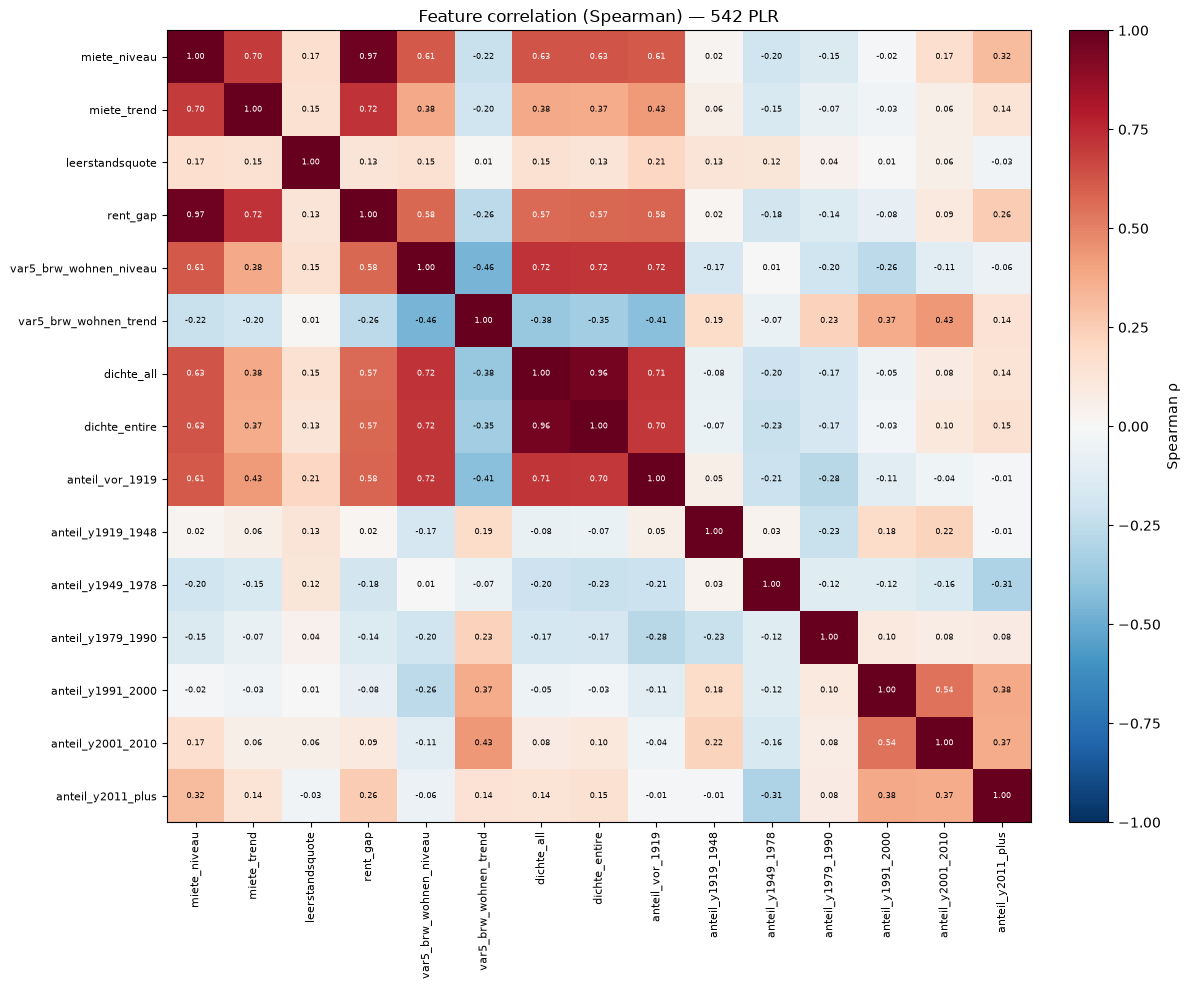

Strong pairs (|ρ| > 0.6):
  miete_niveau                 rent_gap                     +0.97
  dichte_entire                dichte_all                   +0.96
  miete_trend                  rent_gap                     +0.72
  dichte_all                   var5_brw_wohnen_niveau       +0.72
  dichte_entire                var5_brw_wohnen_niveau       +0.72
  anteil_vor_1919              var5_brw_wohnen_niveau       +0.72
  anteil_vor_1919              dichte_all                   +0.71
  dichte_entire                anteil_vor_1919              +0.70
  miete_niveau                 miete_trend                  +0.70
  dichte_entire                miete_niveau                 +0.63
  dichte_all                   miete_niveau                 +0.63
  var5_brw_wohnen_niveau       miete_niveau                 +0.61
  anteil_vor_1919              miete_niveau                 +0.61


In [4]:
#Step 3 - correlation heat matrix 

cs = chk.copy()

feature_cols = [
    "miete_niveau", "miete_trend", "leerstandsquote", "rent_gap",
    "var5_brw_wohnen_niveau", "var5_brw_wohnen_trend",
    "dichte_all", "dichte_entire",
    "anteil_vor_1919", "anteil_y1919_1948", "anteil_y1949_1978",
    "anteil_y1979_1990", "anteil_y1991_2000", "anteil_y2001_2010",
    "anteil_y2011_plus",
]

#Spearman: rank-based, robust to the skew/outliers still present in raw features
corr = cs[feature_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=8)
ax.set_yticklabels(feature_cols, fontsize=8)

#annotate each cell with the correlation value
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6, color="white" if abs(val) > 0.5 else "black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
ax.set_title("Feature correlation (Spearman) — 542 PLR", fontsize=12)
plt.tight_layout()
plt.savefig("../../plots/EDA/real_estate/EDA_correlation.png", dpi=110, bbox_inches="tight")
plt.show()

#print the strongest pairs (|ρ| > 0.6, excluding self-correlations)
print("Strong pairs (|ρ| > 0.6):")
pairs = (corr.where(~np.eye(len(corr), dtype=bool))
             .stack().sort_values(key=abs, ascending=False))
seen = set()
for (a, b), v in pairs.items():
    key = frozenset((a, b))
    if key not in seen and abs(v) > 0.6:
        print(f"  {a:28} {b:28} {v:+.2f}")
        seen.add(key)

### Correlation matrix - Results and Decisions 

Across the 15 candidate features (542 PLR) the Spearman matrix shows two near-perfect redundancies against an otherwise distinct structure. rent_gap tracks miete_niveau at ρ = 0.97 (the gap is dominated by the 2025 asking rent), and dichte_all tracks dichte_entire at ρ = 0.96 (entire-home density is a subset of total). Keeping both members of each pair would double-weight those dimensions in the clustering distance, so rent_gap (also the more incomplete variable) and dichte_entire are dropped as clustering inputs — both stay in the dataset for description and mapping — reducing the feature set from 15 to 13.

The retained features are related but non-redundant. A central axis links high rents, land values, short-let density, and pre-1919 stock (ρ ≈ 0.57–0.72). The land-value trend runs opposite to this axis (ρ ≈ −0.4 to −0.46): the most expensive, high-turnover areas show the steepest land-value declines over 2021–2025, consistent with the post-2022 market correction rather than upgrading. Vacancy is essentially uncorrelated with everything (|ρ| ≤ 0.21), adding independent signal, and the age shares form a composition with weak, partly mechanical correlations — none redundant enough to drop, though their compositional nature will be addressed before clustering, once all three dimensions are merged.

## EDA Step 4: Outliers & Flag Variables

Each real-estate variable carries a reliability flag from its source notebook — thin rent-listing base (miete_unsicher), low residential coverage (cov_wohnen < 0.5), the BRW trend outlier, and few-dwelling PLR (baualter_unsicher). This step overlays each flag on its feature's distribution to check whether low-confidence PLR cluster in the extreme tails — where they would distort clustering — or sit within the dense body, which decides whether any active handling is needed.

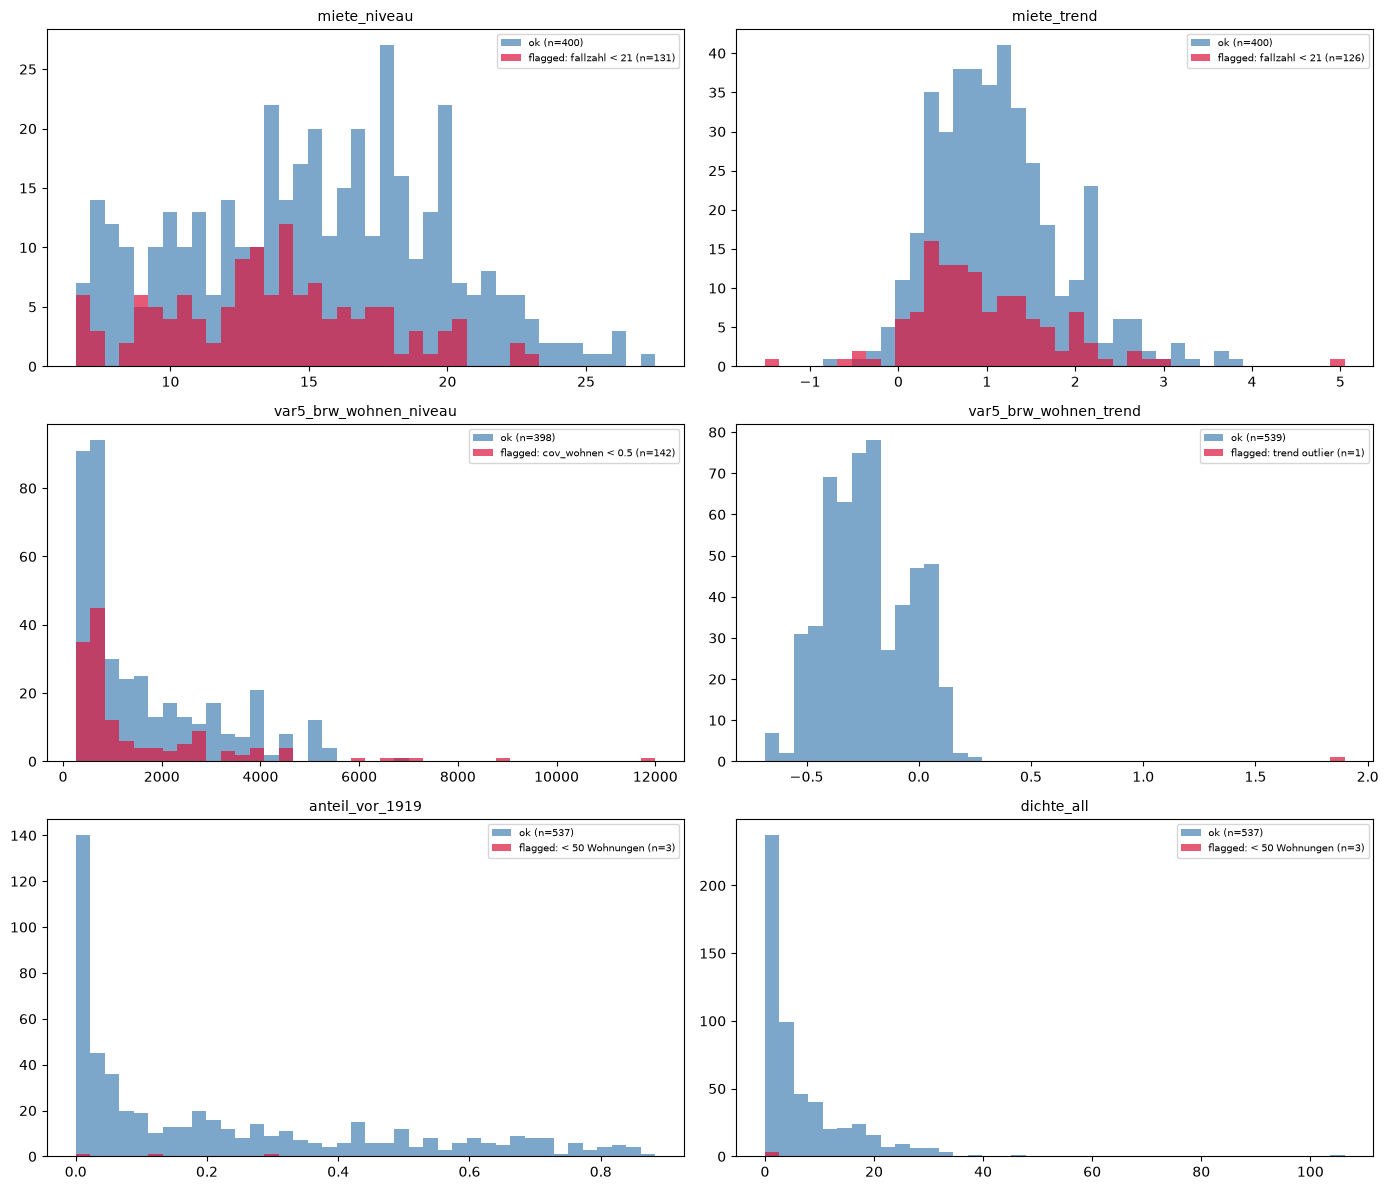

Flagged PLR position within each feature's distribution:
  miete_niveau               [fallzahl < 21     ] flagged median pctile=0.41  share in top/bottom 10%=13%
  miete_trend                [fallzahl < 21     ] flagged median pctile=0.40  share in top/bottom 10%=19%
  var5_brw_wohnen_niveau     [cov_wohnen < 0.5  ] flagged median pctile=0.44  share in top/bottom 10%=25%
  var5_brw_wohnen_trend      [trend outlier     ] flagged median pctile=1.00  share in top/bottom 10%=100%
  anteil_vor_1919            [< 50 Wohnungen    ] flagged median pctile=0.50  share in top/bottom 10%=33%
  dichte_all                 [< 50 Wohnungen    ] flagged median pctile=0.03  share in top/bottom 10%=100%


In [5]:
cs = chk.copy()

# (feature, flag column, flag meaning) — flag relevant to that feature
checks = [
    ("miete_niveau",            cs["miete_unsicher"].fillna(0) == 1,        "fallzahl < 21"),
    ("miete_trend",             cs["miete_unsicher"].fillna(0) == 1,        "fallzahl < 21"),
    ("var5_brw_wohnen_niveau",  cs["cov_wohnen_2025"].fillna(0) < 0.5,      "cov_wohnen < 0.5"),
    ("var5_brw_wohnen_trend",   cs["var5_brw_wohnen_trend_outlier"].fillna(0) == 1, "trend outlier"),
    ("anteil_vor_1919",         cs["baualter_unsicher"].fillna(0) == 1,     "< 50 Wohnungen"),
    ("dichte_all",              cs["baualter_unsicher"].fillna(0) == 1,     "< 50 Wohnungen"),
]

nrows = -(-len(checks) // 2)
fig, axes = plt.subplots(nrows, 2, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, (col, flag_mask, flag_label) in enumerate(checks):
    ax = axes[i]
    ok   = cs.loc[~flag_mask, col].dropna()
    flag = cs.loc[flag_mask,  col].dropna()
    # shared bins so the two overlays are comparable
    allvals = cs[col].dropna()
    bins = 40
    ax.hist(ok,   bins=bins, range=(allvals.min(), allvals.max()),
            color="steelblue", alpha=0.7, label=f"ok (n={len(ok)})")
    ax.hist(flag, bins=bins, range=(allvals.min(), allvals.max()),
            color="crimson", alpha=0.7, label=f"flagged: {flag_label} (n={len(flag)})")
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

for j in range(len(checks), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("../../plots/EDA/real_estate/EDA_flags_overlay.png", dpi=110, bbox_inches="tight")
plt.show()

# numeric companion: where do flagged PLR sit? (median percentile of flagged vs all)
print("Flagged PLR position within each feature's distribution:")
for col, flag_mask, flag_label in checks:
    s = cs[col]
    flagged_vals = s[flag_mask].dropna()
    if len(flagged_vals) == 0:
        continue
    # percentile rank of each flagged PLR within the full distribution
    pct = s.rank(pct=True)[flag_mask].dropna()
    print(f"  {col:26} [{flag_label:18}] "
          f"flagged median pctile={pct.median():.2f}  "
          f"share in top/bottom 10%={(((pct>0.9)|(pct<0.1)).mean()):.0%}")

In [6]:
#check PLR land value outlier to proceed 

chk.loc[chk["var5_brw_wohnen_trend_outlier"]==1, "plr_name"]

235    Gartenfeld
Name: plr_name, dtype: str

## Outlier & Flag Check — Results and Decisions

Overlaying each reliability flag on its feature distribution shows that low-confidence PLR are spread through the dense body of the data rather than isolated in the extreme tails. The two larger flags — thin rent-listing base (miete_unsicher, n = 131) and thin residential coverage (cov_wohnen < 0.5, n = 142) — sit across the rent and land-value distributions with only a mild lean toward lower values, while the two small flags — the single BRW trend outlier (Gartenfeld) and the three PLR with < 50 dwellings — involve too few cases to affect the distribution either way.

Because no flag marks a coherent group of unreliable PLR sitting in the far tails, no active handling (winsorising, exclusion, or down-weighting) is applied at this stage. The flags are retained as descriptive caveats carried alongside the data, so any cluster later found to be driven by flagged PLR can be interpreted with appropriate caution — and any actual exclusion is deferred to the merge stage.



## Correlation check for absolutes and relatives to districts 

Rent and BRW carry both an absolute value (e.g. miete_niveau) and a district-standardised counterpart (miete_niveau_vs_bez), so this step checks how strongly each absolute correlates with its own relative. 

If the two are near-redundant, only one form is needed downstream — which informs the decision to keep the district relatives as descriptives rather than as separate clustering inputs.

saved → plots/correlation_matrix_only_relatives_Bezirk.png


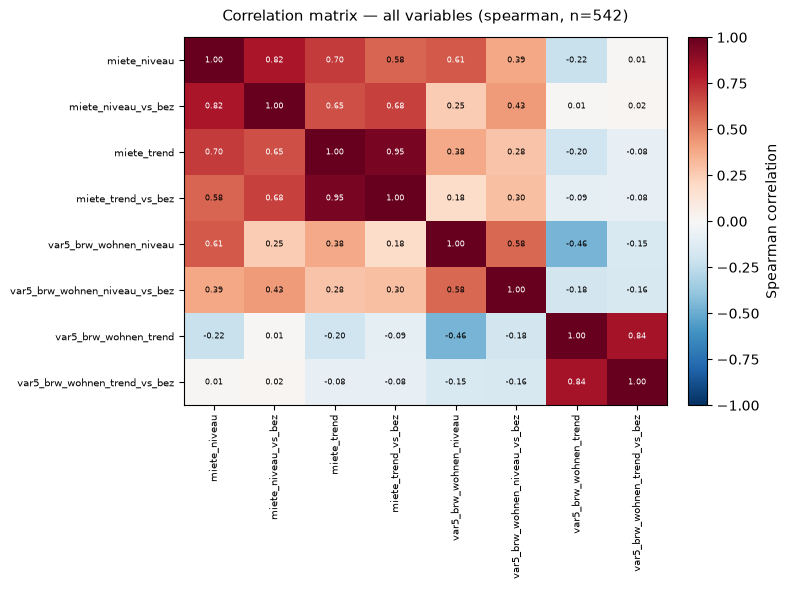

In [7]:
# correlation matrix on the district-relative features — from chk (EDA input, pre-drop)
method = "spearman" 

variables = [
    "miete_niveau", "miete_niveau_vs_bez",
    "miete_trend",  "miete_trend_vs_bez",
    "var5_brw_wohnen_niveau", "var5_brw_wohnen_niveau_vs_bez",
    "var5_brw_wohnen_trend",  "var5_brw_wohnen_trend_vs_bez",
]

missing = [c for c in variables if c not in chk.columns]
if missing:
    print("WARNING — not in chk, dropping:", missing)
variables = [c for c in variables if c in chk.columns]

X = chk[variables].apply(pd.to_numeric, errors="coerce")
corr = X.corr(method="spearman")

#Heatmap
n = len(variables)
fig, ax = plt.subplots(figsize=(max(8, 0.55 * n), max(6, 0.55 * n)))

im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.index, fontsize=7)

#annotate cells 
if n <= 25:
    for i in range(n):
        for j in range(n):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=6, color="white" if abs(v) > 0.6 else "black")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(f"{method.capitalize()} correlation")

ax.set_title(f"Correlation matrix — all variables ({method}, n={len(X)})", fontsize=11, pad=12)
fig.tight_layout()

fig.savefig("../../plots/EDA/real_estate/correlation_matrix_only_relatives_Bezirk.png", dpi=200, bbox_inches="tight")
print("saved → plots/correlation_matrix_only_relatives_Bezirk.png")


### Absolute vs. district-relative — Results and Decision

Each absolute correlates positively with its own district-standardised version, though the strength varies — the trends are near-redundant with their relatives (miete_trend ρ = 0.95, brw_trend ρ = 0.84), rent level is high (ρ = 0.82), and BRW level is moderate (ρ = 0.58). 

Since the relatives largely echo the absolutes, and district/city standardisation is applied later in the modelling pipeline rather than baked into the feature set here, all district relatives are set aside as descriptives — kept for mapping and interpretation — and none are carried into the clustering inputs. 

This keeps the modelling set to the absolute forms alone, avoiding duplicated signal in the clustering distance. The decision is provisional for the current setup; the relatives remain in the data should a later stage call for an explicitly within-district view.

## Final step: Merge Variables 

As the last step, the checked variables are renamed to the shared `re_` prefix and written to `re_variables.csv`, the file that feeds dataset_0. The two redundant clustering inputs identified earlier (rent_gap, ρ = 0.97 with miete_niveau; dichte_entire, ρ = 0.96 with dichte_all) and the district/city relatives are dropped from this model-facing set, while all 542 PLR and their reliability flags are retained — any PLR exclusion is deferred to the merge across all three dimensions.

In [8]:
keys = ["plr_id", "plr_name", "bez"]

rename = {}
for c in chk.columns:
    if c in keys:
        continue
    new = c.replace("var5_brw_wohnen_", "brw_")
    rename[c] = f"re_{new}"

re_variables = (
    chk.rename(columns=rename)
       .drop(columns=["re_rent_gap", "re_dichte_entire",
                      "re_wohnungen", "re_n_missing_vars", "re_miete_niveau_vs_berlin", "re_miete_niveau_vs_bez", "re_miete_trend_vs_berlin", "re_miete_trend_vs_bez", "re_brw_niveau_vs_berlin", "re_brw_niveau_vs_bez", "re_brw_trend_vs_berlin", "re_brw_trend_vs_bez"])
)
#guards
assert all(k in re_variables.columns for k in keys)
assert all(c.startswith("re_") for c in re_variables.columns if c not in keys)
assert "re_miet_dimension_anwendbar" in re_variables.columns
assert "re_rent_gap" not in re_variables.columns
assert "re_dichte_entire" not in re_variables.columns
assert "re_miete_niveau_vs_berlin" not in re_variables.columns
assert "re_miete_niveau_vs_bez" not in re_variables.columns
assert "re_miete_trend_vs_berlin" not in re_variables.columns
assert "re_miete_trend_vs_bez" not in re_variables.columns
assert "re_brw_niveau_vs_berlin" not in re_variables.columns
assert "re_brw_niveau_vs_bez" not in re_variables.columns
assert "re_brw_trend_vs_berlin" not in re_variables.columns
assert "re_brw_trend_vs_bez" not in re_variables.columns

assert re_variables["plr_id"].str.match(r"^\d{8}$").all()
assert len(re_variables) == 542

re_variables.to_csv(csv / "re_variables.csv", index=False)
print("saved:", re_variables.shape, "-> re_variables.csv")
print("\ncolumns:")
for c in re_variables.columns:
    print(" ", c)

saved: (542, 21) -> re_variables.csv

columns:
  plr_id
  plr_name
  bez
  re_miete_niveau
  re_miete_trend
  re_miete_unsicher
  re_leerstandsquote
  re_brw_niveau
  re_brw_trend
  re_brw_trend_outlier
  re_cov_wohnen_2025
  re_dichte_all
  re_baualter_unsicher
  re_anteil_vor_1919
  re_anteil_y1919_1948
  re_anteil_y1949_1978
  re_anteil_y1979_1990
  re_anteil_y1991_2000
  re_anteil_y2001_2010
  re_anteil_y2011_plus
  re_miet_dimension_anwendbar
